[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/14_cicd/lab03_deploy_dns_https_monitoring.ipynb)

# 🧪 Lab 3 — Going live: DNS, reverse proxies, HTTPS & monitoring

> **Module:** CI/CD & Deployment (Module 14) · **Estimated time:** ~60 minutes · **Difficulty:** Intermediate → Advanced

This lab is the hands-on companion to the **going-live chapters** of this module: [deployment.md](deployment.md), [dns.md](dns.md), [reverse-proxies.md](reverse-proxies.md), [https.md](https.md), [monitoring.md](monitoring.md) and [troubleshooting.md](troubleshooting.md). The chapters explain how a request reaches a real server at `203.0.113.10`; in this notebook you **build the whole path yourself** and watch it work — and break, and get fixed.

Everything runs on `127.0.0.1` inside this notebook. No cloud server, no domain, no Docker required — yet nothing here is a slideshow: you will run a **real backend**, a **real reverse proxy you write yourself in ~40 lines**, and a **real uptime monitor**, all offline. When you later rent an actual Ubuntu box and follow [tutorial.md](tutorial.md), every moving part will already be an old friend.

> 🧭 **Mental model: the journey of a request.** Keep one picture in your head for the whole lab — a request travelling from a browser to your app:
>
> **browser → DNS (the internet's phone book) → server IP `:443` → reverse proxy (the receptionist) → app container.**
>
> Each numbered section below owns one leg of that journey: §2 is the phone book, §3–4 are the receptionist and the kitchen, §5 seals the envelope (HTTPS), §6 watches the whole thing breathe (monitoring), §7 is what you do when it stops breathing.

**Prerequisites.** NB 12 (APIs & HTTP — `requests`, status codes, JSON). The sibling labs in this folder — `lab01_docker_and_compose.ipynb` and `lab02_ci_pipeline_github_actions.ipynb` — are helpful context but not required: this lab stands alone.

## 🎯 Learning objectives

By the end of this lab you can:

1. **Trace the full journey of a request** — browser → DNS → server IP → reverse proxy → app container — and name what can fail at each hop.
2. **Simulate the DNS resolution chain** (root → TLD → authoritative nameserver) and explain **A / AAAA / CNAME** records, **TTL**, and why "propagation" is really just caches expiring.
3. **Write a working reverse proxy** in ~40 lines of Python — path routing, `X-Forwarded-For`, friendly `502`s — and map every line onto the real nginx `default.conf` we ship.
4. Explain **what a TLS certificate asserts**, walk the **chain of trust**, and act out the **ACME HTTP-01 challenge** Let's Encrypt uses to issue certificates.
5. Build an **uptime monitor**, survive a (staged) outage, and mine nginx-style **access logs** for the signals that matter: rate, errors, latency.
6. **Diagnose like an operator**: tell a `502` from a `504` from *connection refused* from `NXDOMAIN`, and know the first command to run for each.

## 1. The journey of a request

You type `https://app.example.com` and press Enter. Within a few hundred milliseconds, four very different systems cooperate to put a page on your screen. The chapters call them the **phone book**, the **front door**, the **receptionist**, and the **kitchen** — here is the whole journey in one picture:

```text
        you type https://app.example.com and press Enter
        |
        v
+--------------+  1) "what's the IP for app.example.com?"   +----------------------+
|   Browser    | ------------------------------------------> | DNS — the internet's |
|              | <------------------------------------------ |      phone book      |
+------+-------+  2) "203.0.113.10 — remember it for TTL s"  +----------------------+
       |
       | 3) TCP connect to 203.0.113.10:443  +  TLS handshake (the sealed envelope, §5)
       v
+= the server at 203.0.113.10 =  the restaurant kitchen  ==========================+
|                                                                                  |
|   +------------------------+   4) route by path   +---------------------------+  |
|   |  nginx reverse proxy   | --- /api/* ---------> |  backend container :8000  |  |
|   |  "the receptionist"    |                       |  (FastAPI)                |  |
|   |  listens on :80 / :443 | --- everything else -> |  frontend container :80  |  |
|   +------------------------+                       +---------------------------+  |
|                                                                                  |
+==================================================================================+
```

Read it as a sentence, exactly like the module README does: *the browser asks **DNS** for the IP behind the name, connects to that IP on port 443, the **reverse proxy** receives the request and routes it by path — `/api/...` to the backend container, everything else to the frontend — and carries the answer back.*

Two things are worth saying out loud before we build it:

- **Every hop is a place things fail differently.** A wrong DNS record, a closed firewall port, a dead upstream, an expired certificate — each produces a *distinct* symptom. By the end of this lab (§7) you'll recognize each one on sight.
- **Only the proxy faces the internet.** The backend (`:8000`) and the database are never published; they live on a private Docker network. One controlled front door — that's the receptionist's whole job.

First, a tiny bit of shared infrastructure for the lab. Every server we start must live on **ports 8931–8939** (a quiet corner of the port space so we never collide with anything real), and on a **daemon thread** so it can't outlive the notebook. A small `free_port()` helper saves us from `Address already in use` when you re-run cells.

In [1]:
import json
import re
import socket
import threading
import time
from datetime import datetime, timedelta, timezone
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path

import pandas as pd
import requests

PORT_LO, PORT_HI = 8931, 8939        # this lab's reserved port range
RUNNING_SERVERS = []                 # every server registers here; the 🧹 cleanup cell stops them all


def free_port(start: int = PORT_LO) -> int:
    """First free port in this lab's range, starting at `start`.

    Re-running a cell can leave the old port briefly occupied — instead of
    crashing with EADDRINUSE we simply slide to the next free one.
    """
    for port in range(start, PORT_HI + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
            probe.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            try:
                probe.bind(("127.0.0.1", port))
            except OSError:
                continue             # taken (perhaps by a previous run) — try the next
            return port
    raise RuntimeError(f"no free port in {PORT_LO}-{PORT_HI} — restart the kernel")


def serve_on_thread(server, name: str = "") -> threading.Thread:
    """Run `server.serve_forever()` on a daemon thread and register it for cleanup."""
    thread = threading.Thread(target=server.serve_forever, name=name, daemon=True)
    thread.start()
    RUNNING_SERVERS.append(server)
    return thread


print(f"✅ lab infrastructure ready — servers will use ports {PORT_LO}-{PORT_HI}, all on 127.0.0.1")

✅ lab infrastructure ready — servers will use ports 8931-8939, all on 127.0.0.1


## 2. 🔬 DNS, simulated — the phone book, in three dictionaries

**DNS (Domain Name System)** is the internet's phone book: it maps names humans remember (`example.com`) to numbers machines route by (`203.0.113.10`). The clever part — the part worth simulating — is that *no single server knows the answer*. The answer is assembled by walking a **hierarchy**, exactly as [dns.md](dns.md) §2 describes:

1. **Caches first** — browser, then OS, then the **recursive resolver** (your ISP, or `1.1.1.1`). A cached, unexpired answer stops the journey immediately.
2. **Root nameservers** — don't know `example.com`'s IP, but know who runs `.com`.
3. **TLD nameservers** (`.com`) — don't know the IP either, but know which **authoritative nameserver** holds the records for `example.com`.
4. **Authoritative nameserver** — the source of truth: the server holding the records *you* configured. It answers "`example.com` is `203.0.113.10`".

That hierarchy is just nested lookups — so let's model it as three plain dictionaries. The record types come straight from the chapter: **A** (name → IPv4), **AAAA** (name → IPv6), **CNAME** (name → another name, an alias), each with a **TTL (Time To Live)** — how many seconds caches may keep the answer.

In [2]:
class NXDOMAIN(Exception):
    """DNS-speak for 'this name does not exist'. You'll meet it again in the §7 drill."""


# 1) The root of the tree: doesn't know your domain, but knows who runs each TLD.
ROOT_NAMESERVERS = {
    "com": "a.gtld-servers.net (the .com TLD servers)",
    "org": "a0.org.afilias-nst.info (the .org TLD servers)",
}

# 2) Each TLD: knows which authoritative nameserver holds each domain's records.
TLD_NAMESERVERS = {
    "com": {"example.com": "ns1.example-dns.com"},
}

# 3) The authoritative zone — the records YOU configure at your DNS host.
#    This is the "control panel" table from dns.md §7, as a dict.
ZONE = {
    ("example.com", "A"):          {"value": "203.0.113.10", "ttl": 3600},
    ("example.com", "AAAA"):       {"value": "2001:db8::10", "ttl": 3600},
    ("www.example.com", "CNAME"):  {"value": "example.com",  "ttl": 3600},
    ("app.example.com", "A"):      {"value": "203.0.113.10", "ttl": 300},
}


def show_zone() -> None:
    """Render the zone in classic zone-file format: name  TTL  IN  TYPE  value."""
    print(f"{'name':24s}{'ttl':>6s}  IN  {'type':6s}value")
    print("-" * 62)
    for (name, rtype), rec in sorted(ZONE.items()):
        print(f"{name + '.':24s}{rec['ttl']:6d}  IN  {rtype:6s}{rec['value']}")


show_zone()

name                       ttl  IN  type  value
--------------------------------------------------------------
app.example.com.           300  IN  A     203.0.113.10
example.com.              3600  IN  A     203.0.113.10
example.com.              3600  IN  AAAA  2001:db8::10
www.example.com.          3600  IN  CNAME example.com


Now the star of the section: `resolve()`, a miniature **recursive resolver**. It checks its cache, then walks root → TLD → authoritative, chasing **CNAME** aliases along the way, and finally caches the answer for the record's TTL — printing every hop so you can *watch* the phone book work.

In [3]:
RESOLVER_CACHE = {}   # (name, rtype) -> (value, expires_at): the recursive resolver's memory


def resolve(name: str, rtype: str = "A", quiet: bool = False) -> str:
    """Resolve `name` like a recursive resolver: cache -> root -> TLD -> authoritative."""
    say = (lambda *a: None) if quiet else print
    say(f"🔍 resolving {name}  ({rtype} record)")

    cached = RESOLVER_CACHE.get((name, rtype))
    if cached and cached[1] > time.time():                      # fresh cache hit
        say(f"   ⚡ resolver cache HIT → {cached[0]}  (fresh for another "
            f"{cached[1] - time.time():.0f}s — zero root/TLD/authoritative traffic)")
        return cached[0]

    say("   1. browser / OS / resolver caches … miss (or expired)")
    tld = name.rsplit(".", 1)[-1]
    if tld not in ROOT_NAMESERVERS:
        raise NXDOMAIN(f"root nameserver: no such TLD '.{tld}'")
    say(f"   2. root nameserver … \"I don't know {name} — ask {ROOT_NAMESERVERS[tld]}\"")

    domain = ".".join(name.split(".")[-2:])       # simplification: registrable domain = last two labels
    authoritative = TLD_NAMESERVERS[tld].get(domain)
    if authoritative is None:
        raise NXDOMAIN(f".{tld} TLD nameserver: '{domain}' is not registered")
    say(f"   3. .{tld} TLD nameserver … \"ask {authoritative} — it is authoritative for {domain}\"")

    current = name
    while True:                                   # follow CNAME aliases to the final record
        record = ZONE.get((current, rtype))
        if record is not None:
            say(f"   4. {authoritative} … {rtype} = {record['value']}  (TTL {record['ttl']}s)  ✅")
            RESOLVER_CACHE[(name, rtype)] = (record["value"], time.time() + record["ttl"])
            return record["value"]
        alias = ZONE.get((current, "CNAME"))
        if alias is not None:
            say(f"   4. {authoritative} … CNAME: {current} is an alias for {alias['value']} → chasing it")
            current = alias["value"]
            continue
        raise NXDOMAIN(f"{authoritative}: no {rtype} record for '{current}'")


ip = resolve("app.example.com")
print(f"\n→ the browser can now connect to {ip}\n")

print("the same lookup five seconds later:")
resolve("app.example.com")

🔍 resolving app.example.com  (A record)
   1. browser / OS / resolver caches … miss (or expired)
   2. root nameserver … "I don't know app.example.com — ask a.gtld-servers.net (the .com TLD servers)"
   3. .com TLD nameserver … "ask ns1.example-dns.com — it is authoritative for example.com"
   4. ns1.example-dns.com … A = 203.0.113.10  (TTL 300s)  ✅

→ the browser can now connect to 203.0.113.10

the same lookup five seconds later:
🔍 resolving app.example.com  (A record)
   ⚡ resolver cache HIT → 203.0.113.10  (fresh for another 300s — zero root/TLD/authoritative traffic)


'203.0.113.10'

The first lookup walked the whole chain; the second was answered **instantly from the resolver's cache**. Caching at every level is why DNS scales — and it's also why DNS changes feel slow. Nothing "propagates" when you edit a record: old answers simply sit in caches around the world **until their TTL expires**.

Watch both effects — first a **CNAME chase** (`www` is an alias for the apex), then a **TTL expiry**:

In [4]:
# A CNAME is an alias: www.example.com -> example.com -> 203.0.113.10 (two steps, one answer).
resolve("www.example.com")

print()

# Why do DNS migrations feel slow? Caches hold the OLD answer until the TTL runs out.
# Fast-forward the clock: pretend app.example.com's 300s TTL has just expired.
value, _ = RESOLVER_CACHE[("app.example.com", "A")]
RESOLVER_CACHE[("app.example.com", "A")] = (value, time.time() - 1)   # force-expire the entry
print("after the TTL expires, the resolver must walk the whole chain again:")
resolve("app.example.com")

🔍 resolving www.example.com  (A record)
   1. browser / OS / resolver caches … miss (or expired)
   2. root nameserver … "I don't know www.example.com — ask a.gtld-servers.net (the .com TLD servers)"
   3. .com TLD nameserver … "ask ns1.example-dns.com — it is authoritative for example.com"
   4. ns1.example-dns.com … CNAME: www.example.com is an alias for example.com → chasing it
   4. ns1.example-dns.com … A = 203.0.113.10  (TTL 3600s)  ✅

after the TTL expires, the resolver must walk the whole chain again:
🔍 resolving app.example.com  (A record)
   1. browser / OS / resolver caches … miss (or expired)
   2. root nameserver … "I don't know app.example.com — ask a.gtld-servers.net (the .com TLD servers)"
   3. .com TLD nameserver … "ask ns1.example-dns.com — it is authoritative for example.com"
   4. ns1.example-dns.com … A = 203.0.113.10  (TTL 300s)  ✅


'203.0.113.10'

> ⚠️ **Two classic record mistakes** (both from [dns.md](dns.md)):
>
> 1. **A CNAME at the apex.** The bare `example.com` (the *zone apex*) must be an **A/AAAA** record — the DNS standard forbids a CNAME there. Rule of thumb: **apex = A/AAAA, subdomains = CNAME (or A).**
> 2. **A high TTL right before a migration.** If resolvers cached your record for 24 hours, some visitors hit the old server for a full day after you switch. Lower the TTL to ~300s a day *before* the move, migrate, verify, then raise it back.
>
> Notice `app.example.com` above already uses `ttl: 300` — that's a record its operator expects to move soon.

---

### ✋ Quick exercise (~2 min) — Publish a `blog.` alias

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Marketing wants `blog.example.com` to open the main site. Publish a **CNAME** record in the authoritative `ZONE` that aliases `blog.example.com` to the apex `example.com` (TTL 3600), then `resolve("blog.example.com")` and confirm the resolver chases the alias to the apex **A** record and answers `203.0.113.10`.

In [5]:
# ✍️ Your turn 👇
# 1) publish the record in the authoritative zone (key: (name, type), value: {"value": ..., "ttl": ...})
#    ZONE[("blog.example.com", "CNAME")] = ...
#
# 2) resolve it — watch the resolver chase the alias to the apex A record:
#    resolve("blog.example.com")
...

Ellipsis

<details>
<summary>✅ <b>Solution</b></summary>

```python
ZONE[("blog.example.com", "CNAME")] = {"value": "example.com", "ttl": 3600}

answer = resolve("blog.example.com")
print(f"\n→ blog.example.com resolves to {answer}")
```

The authoritative server first answers with the **CNAME** (`blog.example.com` → `example.com`), and the resolver *chases* the alias: it looks up `example.com`'s **A** record and returns `203.0.113.10`. This is exactly why aliases are useful — when the server moves, you update **one** apex A record and every CNAME (`www`, `blog`, …) follows automatically.
</details>

**One optional reality check.** Everything above was a simulation — but the real phone book speaks the same protocol. If this machine happens to be online, the cell below asks your **real OS resolver** (the same lookup `dig +short example.com` or `nslookup example.com` performs). Offline? It degrades gracefully — the whole lab keeps working.

In [6]:
# 🌐 OPTIONAL — the only cell in this lab that touches the real network. Safe to skip.
try:
    infos = socket.getaddrinfo("example.com", 443, proto=socket.IPPROTO_TCP)
    real_ips = sorted({info[4][0] for info in infos})
    print("real DNS answer for example.com, via your OS resolver (≈ `dig +short example.com`):")
    for addr in real_ips:
        kind = "AAAA (IPv6)" if ":" in addr else "A    (IPv4)"
        print(f"   {kind}  {addr}")
except OSError:
    print("offline — using the simulator above. (Online you'd see the real A/AAAA records here.)")

real DNS answer for example.com, via your OS resolver (≈ `dig +short example.com`):
   A    (IPv4)  104.20.23.154
   A    (IPv4)  172.66.147.243


## 3. A tiny backend, live

DNS got the browser to the server's front door. Time to put something *behind* the door.

In the example app, the backend is a **FastAPI container** ([`example-app/backend/app/main.py`](example-app/backend/app/main.py)) listening on `backend:8000`, with two endpoints every chapter leans on:

- `GET /api/health` → `{"status": "ok"}` — the **liveness probe** Docker's `HEALTHCHECK` and our monitoring poll,
- `GET /api/message` → a hello-world payload the frontend renders.

We'll stand up a faithful miniature: a `ThreadingHTTPServer` on a **daemon thread** playing the role of the app container. Its routes live in a plain dict, `BACKEND_ROUTES`, that the handler consults **on every request** — so we can teach it new endpoints later *without restarting it* (remember this; it pays off twice).

> 🧠 **Mental model.** This server *is* the kitchen from the chapters: it cooks exactly what's ordered and knows nothing about the outside world. It shouldn't be reachable from the internet at all — making sure of that is the receptionist's job in §4.

In [7]:
# Routes as data: path -> function(handler) -> JSON-serializable payload.
# The handler consults this dict per request, so new routes need no restart.
BACKEND_ROUTES = {
    "/api/health":  lambda handler: {"status": "ok"},
    "/api/message": lambda handler: {"message": "Hello from the backend container"},
}


class QuietServer(ThreadingHTTPServer):
    """ThreadingHTTPServer that keeps notebook output clean."""
    daemon_threads = True                      # request threads die with the kernel

    def handle_error(self, request, client_address):
        pass                                   # a dropped connection is not news


class BackendHandler(BaseHTTPRequestHandler):
    """Stands in for the FastAPI app container (example-app/backend/app/main.py)."""

    def do_GET(self):
        route = BACKEND_ROUTES.get(self.path.split("?")[0])
        if route is None:
            payload, status = {"detail": "Not Found"}, 404       # FastAPI's 404 body
        else:
            try:
                payload, status = route(self), 200
            except Exception as exc:                             # an app bug → HTTP 500
                payload, status = {"detail": f"internal error: {exc}"}, 500
        body = json.dumps(payload).encode()
        self.send_response(status)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    def log_message(self, *_):                                   # silence stderr chatter
        pass


def start_backend(port: int) -> QuietServer:
    server = QuietServer(("127.0.0.1", port), BackendHandler)
    serve_on_thread(server, name=f"backend:{port}")
    return server


BACKEND_PORT = free_port(8931)
backend_server = start_backend(BACKEND_PORT)
print(f"🚀 backend 'container' listening on http://127.0.0.1:{BACKEND_PORT}"
      f"   (playing the role of backend:8000 on the appnet network)")

🚀 backend 'container' listening on http://127.0.0.1:8931   (playing the role of backend:8000 on the appnet network)


It's a real HTTP server now — let's hit it with `requests`, exactly as you learned in NB 12. (Calling `127.0.0.1` is still offline: the bytes never leave your machine.)

In [8]:
base = f"http://127.0.0.1:{BACKEND_PORT}"

print("GET /api/health  →", requests.get(base + "/api/health",  timeout=2).json())
print("GET /api/message →", requests.get(base + "/api/message", timeout=2).json())

resp = requests.get(base + "/api/nope", timeout=2)               # an unknown route
print(f"GET /api/nope    → {resp.status_code} {resp.json()}")

GET /api/health  → {'status': 'ok'}
GET /api/message → {'message': 'Hello from the backend container'}
GET /api/nope    → 404 {'detail': 'Not Found'}


## 4. Write your own reverse proxy

Right now, anyone would have to know (and reach) the backend's port directly. Real stacks never allow that. A **reverse proxy** — *the receptionist* — is the single front door: it receives **every** request, routes each one to the right internal service by path, and carries the reply back. The visitor never learns the building's internal layout.

Ours must do exactly what the shipped nginx config does, plus one hook we'll need in §5:

| rule | who answers |
|---|---|
| `/.well-known/acme-challenge/*` | the proxy itself (HTTPS certificate proof — empty until §5) |
| `/api/*` | forwarded to the **backend** upstream |
| everything else | a static **frontend** page |

Three behaviors separate a toy from a receptionist, and we implement all three:

1. **Forwarded headers.** To the backend, every request would look like it came *from the proxy*. The receptionist writes the visitor's details on the message: `X-Forwarded-For` (the real client IP), `Host`, and `X-Forwarded-Proto` (did the visitor arrive over http or https?).
2. **A friendly `502 Bad Gateway`** when the upstream is down — "I'm at the front desk, but the room isn't answering."
3. **A `504 Gateway Timeout`** when the upstream answers too slowly — nginx's `proxy_read_timeout`, ours is `PROXY_TIMEOUT = 1.0` s.

And like real nginx, it keeps an **access log** — one line per request — which becomes raw material for §6.

In [9]:
FRONTEND_HTML = '''<!doctype html>
<title>example.com</title>
<h1>🐍 Hello from the frontend "container"</h1>
<p>Served by the reverse proxy's <code>location /</code> rule.
   The API lives under <a href="/api/message">/api/message</a> — same origin, no CORS drama.</p>
'''

# Our "upstream block": name -> base URL. nginx: upstream backend_upstream { server backend:8000; }
UPSTREAMS = {"backend": f"http://127.0.0.1:{BACKEND_PORT}"}

ACME_CHALLENGES = {}        # token -> proof; §5 (HTTPS) fills this, exactly like certbot does
ACCESS_LOG = []             # our /var/log/nginx/access.log
PROXY_TIMEOUT = 1.0         # seconds we wait for the upstream (nginx: proxy_read_timeout)


def nginx_log_line(ip: str, path: str, status: int, nbytes: int, seconds: float) -> str:
    """One access-log line in nginx's 'combined' format + trailing $request_time."""
    stamp = datetime.now(timezone.utc).strftime("%d/%b/%Y:%H:%M:%S +0000")
    return f'{ip} - - [{stamp}] "GET {path} HTTP/1.1" {status} {nbytes} "-" "lab-client/1.0" {seconds:.3f}'


class ReverseProxyHandler(BaseHTTPRequestHandler):
    """A receptionist in ~40 lines: route by path, forward with headers, fail politely."""

    def do_GET(self):
        started = time.perf_counter()
        status, body, ctype = self.route()
        self.send_response(status)
        self.send_header("Content-Type", ctype)
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)
        ACCESS_LOG.append(nginx_log_line(self.client_address[0], self.path,
                                         status, len(body), time.perf_counter() - started))

    def route(self):
        # Rule 1 — ACME challenges: answered by the proxy itself (see §5).
        if self.path.startswith("/.well-known/acme-challenge/"):
            token = self.path.rsplit("/", 1)[-1]
            if token in ACME_CHALLENGES:
                return 200, ACME_CHALLENGES[token].encode(), "text/plain"
            return 404, b"no such challenge", "text/plain"

        # Rule 2 — /api/* -> backend upstream.   nginx: location /api/ { proxy_pass ... }
        if self.path.startswith("/api/"):
            forwarded = {                                        # nginx: proxy_set_header ...
                "Host": self.headers.get("Host", ""),
                "X-Real-IP": self.client_address[0],
                "X-Forwarded-For": self.client_address[0],
                "X-Forwarded-Proto": "http",
            }
            try:   # NOTE: upstream + self.path keeps the /api/ prefix — see the pitfall below
                resp = requests.get(UPSTREAMS["backend"] + self.path,
                                    headers=forwarded, timeout=PROXY_TIMEOUT)
                return resp.status_code, resp.content, resp.headers.get("Content-Type", "application/json")
            except requests.exceptions.Timeout:                  # alive, but too slow
                return 504, json.dumps({"error": "504 Gateway Timeout",
                                        "hint": f"the upstream took longer than {PROXY_TIMEOUT}s to answer"}).encode(), "application/json"
            except requests.exceptions.ConnectionError:          # nobody home
                return 502, json.dumps({"error": "502 Bad Gateway",
                                        "hint": "the proxy is fine, but the backend upstream is not answering — is the app container running?"}).encode(), "application/json"

        # Rule 3 — everything else -> frontend.   nginx: location / { proxy_pass ... }
        return 200, FRONTEND_HTML.encode(), "text/html"

    def log_message(self, *_):
        pass


PROXY_PORT = free_port(8932)
proxy_server = QuietServer(("127.0.0.1", PROXY_PORT), ReverseProxyHandler)
serve_on_thread(proxy_server, name=f"proxy:{PROXY_PORT}")

print(f"🚪 reverse proxy (the receptionist) listening on http://127.0.0.1:{PROXY_PORT}\n")
print("route table:")
print(f"   /.well-known/acme-challenge/*  → answered by the proxy itself (§5)")
print(f"   /api/*                         → backend upstream at {UPSTREAMS['backend']}")
print(f"   /* (everything else)           → static frontend (inline HTML)")

🚪 reverse proxy (the receptionist) listening on http://127.0.0.1:8932

route table:
   /.well-known/acme-challenge/*  → answered by the proxy itself (§5)
   /api/*                         → backend upstream at http://127.0.0.1:8931
   /* (everything else)           → static frontend (inline HTML)


One front door, three rooms. Let's knock — every request now goes through the **proxy's** port, and the visitor never learns the backend's:

In [10]:
front_door = f"http://127.0.0.1:{PROXY_PORT}"

page = requests.get(front_door + "/", timeout=3)                     # -> frontend
print(f"GET /             → {page.status_code} ({page.headers['Content-Type']}), "
      f"starts: {page.text.splitlines()[1][:26]!r}")

print("GET /api/health   →", requests.get(front_door + "/api/health",  timeout=3).json())
print("GET /api/message  →", requests.get(front_door + "/api/message", timeout=3).json())

print("\nthe proxy's access log so far (nginx 'combined' format + request time):")
for line in ACCESS_LOG[-3:]:
    print("  ", line)

GET /             → 200 (text/html), starts: '<title>example.com</title>'
GET /api/health   → {'status': 'ok'}
GET /api/message  → {'message': 'Hello from the backend container'}

the proxy's access log so far (nginx 'combined' format + request time):
   127.0.0.1 - - [03/Jul/2026:20:29:29 +0000] "GET / HTTP/1.1" 200 255 "-" "lab-client/1.0" 0.000
   127.0.0.1 - - [03/Jul/2026:20:29:29 +0000] "GET /api/health HTTP/1.1" 200 16 "-" "lab-client/1.0" 0.001
   127.0.0.1 - - [03/Jul/2026:20:29:29 +0000] "GET /api/message HTTP/1.1" 200 47 "-" "lab-client/1.0" 0.001


### The real thing, line by line

Our Python receptionist is a translation of the **actual** nginx config the example app ships. Load it (locally if you have the repo, from GitHub otherwise, from a bundled copy if offline) and put the two side by side:

In [11]:
NGINX_CONF_FALLBACK = '''# Upstreams name the internal containers. Docker's DNS resolves these
# service names ("frontend", "backend") to container IPs on the appnet network.
upstream frontend_upstream {
    server frontend:80;
}
upstream backend_upstream {
    server backend:8000;
}

server {
    listen 80;
    server_name _;            # match any hostname for now (see https.md for TLS)

    # API traffic -> FastAPI backend. The trailing slashes keep the /api/ prefix.
    location /api/ {
        proxy_pass http://backend_upstream;
        proxy_set_header Host              $host;
        proxy_set_header X-Real-IP         $remote_addr;
        proxy_set_header X-Forwarded-For   $proxy_add_x_forwarded_for;
        proxy_set_header X-Forwarded-Proto $scheme;
    }

    # Everything else -> static frontend.
    location / {
        proxy_pass http://frontend_upstream;
        proxy_set_header Host              $host;
        proxy_set_header X-Real-IP         $remote_addr;
        proxy_set_header X-Forwarded-For   $proxy_add_x_forwarded_for;
        proxy_set_header X-Forwarded-Proto $scheme;
    }
}
'''

nginx_conf = None
for candidate in (Path("example-app/nginx/default.conf"),               # run from 14_cicd/
                  Path("14_cicd/example-app/nginx/default.conf")):      # run from the repo root
    if candidate.exists():
        nginx_conf = candidate.read_text()
        print(f"(loaded the real {candidate})\n")
        break
if nginx_conf is None:
    try:                                                                 # e.g. on Colab
        raw_url = ("https://raw.githubusercontent.com/ChrisW09/"
                   "Python-for-AI-Driven-Automation/main/14_cicd/example-app/nginx/default.conf")
        fetched = requests.get(raw_url, timeout=5)
        fetched.raise_for_status()
        nginx_conf = fetched.text
        print("(loaded default.conf from GitHub)\n")
    except requests.exceptions.RequestException:
        nginx_conf = NGINX_CONF_FALLBACK
        print("(offline — using the bundled copy)\n")

print(nginx_conf)

(loaded the real example-app/nginx/default.conf)

# Upstreams name the internal containers. Docker's DNS resolves these
# service names ("frontend", "backend") to container IPs on the appnet network.
upstream frontend_upstream {
    server frontend:80;
}
upstream backend_upstream {
    server backend:8000;
}

server {
    listen 80;
    server_name _;            # match any hostname for now (see https.md for TLS)

    # API traffic -> FastAPI backend. The trailing slashes keep the /api/ prefix.
    location /api/ {
        proxy_pass http://backend_upstream;
        proxy_set_header Host              $host;
        proxy_set_header X-Real-IP         $remote_addr;
        proxy_set_header X-Forwarded-For   $proxy_add_x_forwarded_for;
        proxy_set_header X-Forwarded-Proto $scheme;
    }

    # Everything else -> static frontend.
    location / {
        proxy_pass http://frontend_upstream;
        proxy_set_header Host              $host;
        proxy_set_header X-Real-IP         $

Every nginx directive has a twin in the proxy you just wrote:

| nginx (`default.conf`) | our Python proxy | the job |
|---|---|---|
| `upstream backend_upstream { server backend:8000; }` | `UPSTREAMS = {"backend": f"http://127.0.0.1:{BACKEND_PORT}"}` | name the internal service (Docker's DNS ↔ our dict) |
| `listen 80;` | `QuietServer(("127.0.0.1", PROXY_PORT), …)` | the single front door |
| `location /api/ { … }` | `if self.path.startswith("/api/"):` | route by path prefix (most-specific wins) |
| `proxy_pass http://backend_upstream;` *(no trailing slash)* | `requests.get(UPSTREAMS["backend"] + self.path, …)` | forward with the `/api/` prefix **preserved** |
| `proxy_set_header Host $host;` | `"Host": self.headers.get("Host", "")` | keep the original hostname for redirects/links |
| `proxy_set_header X-Real-IP / X-Forwarded-For …` | `"X-Forwarded-For": self.client_address[0]` | restore the real caller's IP |
| `proxy_set_header X-Forwarded-Proto $scheme;` | `"X-Forwarded-Proto": "http"` | tell the app whether the visitor used https (§5) |
| `location / { proxy_pass http://frontend_upstream; }` | final `return 200, FRONTEND_HTML…` | everything else → frontend |
| *(built-in)* `502 Bad Gateway` | `except ConnectionError → 502` | upstream down, proxy honest about it |
| `proxy_read_timeout` *(default 60s)* | `timeout=PROXY_TIMEOUT` → `504` | upstream too slow |
| `access_log /var/log/nginx/access.log;` | `ACCESS_LOG.append(…)` | the diary we'll mine in §6 |

> ⚠️ **The trailing-slash trap** ([reverse-proxies.md](reverse-proxies.md) §3). In nginx, `proxy_pass http://backend_upstream;` (no trailing slash) forwards `/api/health` **unchanged**; add a trailing slash and nginx *strips* the matched `/api/` prefix, the backend receives `/health`, and every API call 404s — because the FastAPI routes are defined *with* the prefix (`@app.get("/api/health")`). Our Python twin makes the same choice explicitly: `UPSTREAMS["backend"] + self.path`. You'll debug exactly this bug in Exercise 4. 🐞
>
> ⚠️ **`localhost` is not your friend inside containers.** In the real stack the upstream must be `server backend:8000;` — the Docker *service name*. Point it at `localhost:8000` and nginx talks to *itself* (each container has its own loopback). Our dict makes the indirection visible: the proxy looks up its target per request, just like nginx resolves service names on `appnet`.

---

### ✋ Quick exercise (~2 min) — Who is really calling?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Prove the forwarded headers matter. Teach the backend one new endpoint — `/api/whoami` — that returns the `X-Forwarded-For` header it received (or `None` if absent). No restart needed: just add an entry to `BACKEND_ROUTES` (the handler reads it per request — inside a route function, `handler.headers.get(...)` reads a request header).

Then call it twice and compare: **directly** on the backend port, and **through the proxy**. Which call carries the real client IP?

In [12]:
# ✍️ Your turn 👇
# 1) teach the backend a new route — no restart required:
# BACKEND_ROUTES["/api/whoami"] = lambda handler: {
#     "x_forwarded_for": handler.headers.get("X-Forwarded-For"),
# }

# 2) call it both ways and compare:
# direct    = requests.get(f"http://127.0.0.1:{BACKEND_PORT}/api/whoami", timeout=2).json()
# via_proxy = requests.get(f"http://127.0.0.1:{PROXY_PORT}/api/whoami",  timeout=2).json()
# print("direct:   ", direct)
# print("via proxy:", via_proxy)
...

Ellipsis

<details>
<summary>✅ <b>Solution</b></summary>

```python
BACKEND_ROUTES["/api/whoami"] = lambda handler: {
    "x_forwarded_for": handler.headers.get("X-Forwarded-For"),
}

direct    = requests.get(f"http://127.0.0.1:{BACKEND_PORT}/api/whoami", timeout=2).json()
via_proxy = requests.get(f"http://127.0.0.1:{PROXY_PORT}/api/whoami",  timeout=2).json()
print("direct:   ", direct)      # None — nobody set the header
print("via proxy:", via_proxy)   # the visitor's IP, restored by the receptionist
```

Called **directly**, the backend sees no `X-Forwarded-For` at all. Called **through the proxy**, the header carries the true client address (`127.0.0.1` here — us). Without the `proxy_set_header` lines, every backend log would blame one "visitor": the proxy itself. That's why [reverse-proxies.md](reverse-proxies.md) insists on forwarding all four headers on every proxied location.
</details>

## 5. HTTPS without the hand-waving

So far every byte between "browser" and proxy travels as **plaintext HTTP** — a postcard anyone on the path can read *and modify*: URLs, cookies, tokens, bodies. **HTTPS** is the same HTTP inside a **TLS** tunnel — a sealed, tamper-evident envelope. (You'll still hear "SSL"; SSL is the broken 1990s ancestor — what actually runs today is **TLS 1.2/1.3**.)

But encryption alone isn't enough — encrypting traffic *to an impostor* would be worse than useless. So before any HTTP flows, the server must **prove it really is `example.com`**. That proof is a **TLS certificate**.

**What a certificate actually asserts** — nothing more, nothing less:

> *"A Certificate Authority your browser already trusts confirms that the holder of this public key controls the name `example.com` — until this expiry date."*

It does **not** assert the site is honest, safe, or well-run. It authenticates a *name*, and it does so via a **chain of trust**:

```text
Root CA  (pre-installed in your OS/browser "trust store"; its key kept offline)
   └── signs →  Intermediate CA   (does the day-to-day signing)
                   └── signs →  Leaf certificate for example.com   (your cert)
```

During the **TLS handshake** the server presents *leaf + intermediates*; the browser walks the chain upward until it reaches a root it already trusts, then checks the **name matches** and the cert is **not expired**. All three checks pass → padlock; break any link → scary warning.

> 🔬 **Deep dive: SNI (Server Name Indication).** One server IP often hosts many domains, each with its own certificate — but the certificate must be chosen *before* any HTTP (with its `Host` header) can be decrypted. Chicken and egg? SNI solves it: the browser includes the hostname **in plaintext inside the ClientHello**, the very first handshake message. That's how nginx picks the right cert per `server_name` — and why, once TLS arrives, the config pins `server_name example.com www.example.com` instead of the catch-all `_`.

**Where does the certificate come from?** [https.md](https.md) §4: **Let's Encrypt** — a free, automated CA. Its **ACME** protocol issues certificates to *programs*, not paperwork, using the **HTTP-01 challenge**:

1. Your ACME client (certbot) asks the CA for a certificate for `example.com`.
2. The CA invents a **random token** and replies: *"prove control — serve this token at `http://example.com/.well-known/acme-challenge/<token>`."*
3. The client installs the token where the web server will serve it (this is why our proxy has Rule 1!).
4. The CA **resolves your domain via DNS** and fetches that URL on port **80**. Token matches → you demonstrably control the domain → **certificate issued** (valid **90 days**, renewed automatically around day 60).

Notice the dependency order the chapters keep repeating: **DNS must point at your server first** (the CA validates by *reaching* your domain), and **port 80 must be open** (the challenge travels over plain HTTP). Our simulation honors both — the "CA" below calls our `resolve()` before fetching the token from our proxy.

In [13]:
import secrets

TRUST_STORE = {"Lab Root CA R1"}          # what "ships with the browser/OS"


def ca_issue_certificate(domain: str, challenge_port: int) -> dict:
    """A miniature Let's Encrypt: prove control of `domain` via HTTP-01, then issue."""
    print(f"📨 order received: certificate for '{domain}'")

    # Step 1 — the CA invents a random token for this order.
    token = secrets.token_urlsafe(12)
    proof = f"{token}.lab-account-key-thumbprint"
    print(f"   1. CA → client:  \"serve '{token[:10]}…' at /.well-known/acme-challenge/\"")

    # Step 2 — the ACME client (certbot's job) installs it where the proxy serves it.
    ACME_CHALLENGES[token] = proof
    print("   2. client → proxy: token installed  (certbot does this to your nginx)")

    # Step 3 — the CA resolves the domain via DNS… which is why DNS must be correct FIRST.
    ip = resolve(domain, quiet=True)
    print(f"   3. CA resolves {domain} → {ip} and fetches the challenge over plain HTTP :80")
    print(f"      (in our sandbox that server is really 127.0.0.1:{challenge_port})")
    fetched = requests.get(
        f"http://127.0.0.1:{challenge_port}/.well-known/acme-challenge/{token}", timeout=3)
    if fetched.status_code != 200 or fetched.text != proof:
        raise RuntimeError("HTTP-01 challenge failed — control of the domain NOT proven")
    print("   4. token matches — control of the domain proven ✅")

    # Step 4 — the CA signs a 90-day certificate (Let's Encrypt's lifetime).
    now = datetime.now(timezone.utc)
    issued = {
        "subject":    domain,
        "sans":       [domain],                        # names this cert is valid for
        "issuer":     "Lab Intermediate CA X9",
        "chain":      ["Lab Intermediate CA X9", "Lab Root CA R1"],
        "not_before": now.isoformat(timespec="seconds"),
        "not_after":  (now + timedelta(days=90)).isoformat(timespec="seconds"),
        "serial":     secrets.token_hex(8),
    }
    del ACME_CHALLENGES[token]                         # tidy up, like certbot does
    print(f"   5. 🪪 certificate issued — serial {issued['serial']}, valid 90 days")
    return issued


cert = ca_issue_certificate("app.example.com", PROXY_PORT)
cert

📨 order received: certificate for 'app.example.com'
   1. CA → client:  "serve 'ypiAFe4ELf…' at /.well-known/acme-challenge/"
   2. client → proxy: token installed  (certbot does this to your nginx)
   3. CA resolves app.example.com → 203.0.113.10 and fetches the challenge over plain HTTP :80
      (in our sandbox that server is really 127.0.0.1:8932)
   4. token matches — control of the domain proven ✅
   5. 🪪 certificate issued — serial 30a40149758f3530, valid 90 days


{'subject': 'app.example.com',
 'sans': ['app.example.com'],
 'issuer': 'Lab Intermediate CA X9',
 'chain': ['Lab Intermediate CA X9', 'Lab Root CA R1'],
 'not_before': '2026-07-03T20:29:29+00:00',
 'not_after': '2026-10-01T20:29:29+00:00',
 'serial': '30a40149758f3530'}

That dictionary is (structurally) what `certbot` writes to `/etc/letsencrypt/live/example.com/` as `fullchain.pem` — minus the actual cryptography. Now play **browser**: on connect, the server presents this cert, and the browser runs the three handshake checks from [https.md](https.md) §3 before a single byte of HTTP flows.

In [14]:
def browser_would_trust(certificate: dict, hostname: str) -> bool:
    """The three checks a browser runs on the presented certificate chain."""
    now_iso = datetime.now(timezone.utc).isoformat(timespec="seconds")
    checks = {
        f"name matches '{hostname}'":       hostname in certificate["sans"],
        "not expired":                      certificate["not_before"] <= now_iso < certificate["not_after"],
        "chain ends at a trusted root":     certificate["chain"][-1] in TRUST_STORE,
    }
    for label, ok in checks.items():
        print(f"   {'✅' if ok else '❌'} {label}")
    verdict = all(checks.values())
    print("   →", "🔒 padlock — proceed with the TLS handshake" if verdict
          else "⚠️ 'Your connection is not private'")
    return verdict


print("browser connecting to https://app.example.com …")
browser_would_trust(cert, "app.example.com")

print("\nan impostor presents the same cert for a different site …")
browser_would_trust(cert, "evil.example.com")

browser connecting to https://app.example.com …
   ✅ name matches 'app.example.com'
   ✅ not expired
   ✅ chain ends at a trusted root
   → 🔒 padlock — proceed with the TLS handshake

an impostor presents the same cert for a different site …
   ❌ name matches 'evil.example.com'
   ✅ not expired
   ✅ chain ends at a trusted root
   → ⚠️ 'Your connection is not private'


False

**Where TLS actually terminates.** In the real stack, none of this lives in your Python app: **TLS terminates at the nginx reverse proxy**. Certbot adds a `listen 443 ssl;` server block pointing at `fullchain.pem`/`privkey.pem`, plus a port-80 block whose only job is `return 301 https://$host$request_uri;`. Behind the proxy, traffic to the containers stays **plain HTTP on the private appnet** — which is exactly why the `X-Forwarded-Proto` header from §4 exists: it's the only way the backend learns the visitor really came over HTTPS.

> ⚠️ **The HTTPS pitfalls that page people at 2 a.m.** (all from [https.md](https.md)):
> - **Port 80 or 443 blocked** → the challenge can't be fetched / visitors can't connect. Open both: `sudo ufw allow 80/tcp && sudo ufw allow 443/tcp`.
> - **DNS not pointing at the server yet** → issuance fails; the CA validates by *reaching* you. DNS first, certificates second.
> - **Re-issuing in a test loop** → Let's Encrypt rate limits. Practice with `certbot --dry-run` / the staging environment.
> - **Forgotten renewal** → the cert silently expires on day 90 and every visitor sees a warning. The certbot package installs a systemd timer; *verify* it with `sudo certbot renew --dry-run`.

---

### ✋ Quick exercise (~2 min) — The renewal robot's brain

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Let's Encrypt certificates live 90 days, so renewal must be automatic — certbot's timer renews anything within ~30 days of expiry. Write the two functions that timer needs:

- `days_until_expiry(certificate)` → whole days until `certificate["not_after"]` (hint: `datetime.fromisoformat(...)`, subtract `datetime.now(timezone.utc)`, take `.days`);
- `needs_renewal(certificate, renew_before_days=30)` → `True` once expiry is that close.

Run both on the `cert` you just issued — a fresh 90-day cert should **not** need renewal.

In [15]:
# ✍️ Your turn 👇
def days_until_expiry(certificate: dict) -> int:
    # parse certificate["not_after"], subtract "now" (UTC), return the .days
    ...

def needs_renewal(certificate: dict, renew_before_days: int = 30) -> bool:
    # True once we're within `renew_before_days` of expiry
    ...

# print(days_until_expiry(cert), "days left — renew now?", needs_renewal(cert))

<details>
<summary>✅ <b>Solution</b></summary>

```python
def days_until_expiry(certificate: dict) -> int:
    expires = datetime.fromisoformat(certificate["not_after"])
    return (expires - datetime.now(timezone.utc)).days

def needs_renewal(certificate: dict, renew_before_days: int = 30) -> bool:
    return days_until_expiry(certificate) <= renew_before_days

print(days_until_expiry(cert), "days left — renew now?", needs_renewal(cert))

# what certbot's twice-daily timer effectively does:
almost_expired = dict(cert, not_after=(datetime.now(timezone.utc) + timedelta(days=12)).isoformat(timespec="seconds"))
print(days_until_expiry(almost_expired), "days left — renew now?", needs_renewal(almost_expired))
```

A fresh cert has ~89 days left → no renewal. The doctored copy with 12 days left trips the 30-day threshold → renew. This tiny decision, run twice a day by a systemd timer, is the entire difference between "HTTPS just works for years" and the Exercise-3 horror story in [https.md](https.md): a site that dies on day 91.
</details>

## 6. Monitoring — is it actually working?

The stack is live. Now the question every operator eventually asks at 2 a.m.: *"is it actually working — and if not, why?"* Running a server without monitoring is running a kitchen with no thermometers and no smoke detector: fine, until a customer tells you it isn't.

[monitoring.md](monitoring.md) builds on the **three pillars of observability** — **logs** (*what happened?*), **metrics** (*how much / how fast?*), traces — and we'll build working miniatures of the first two:

1. an **uptime monitor**: the outside-in metric — poll `/api/health` *through the front door* and record status + latency, exactly what Docker's `HEALTHCHECK` and a paid uptime service do;
2. an **access-log analysis**: mine nginx-style logs for request rate, error rate, and slow paths.

And because monitoring is only interesting when something breaks… we will **stage an outage** and watch the monitor catch it.

In [16]:
HEALTH_URL = f"http://127.0.0.1:{PROXY_PORT}/api/health"     # through the front door, like a real user


def check_health(url: str, timeout: float = 1.5) -> dict:
    """One probe: GET `url`, record status + latency. Never raises — a monitor that
    crashes when the target is down would be a smoke detector that melts in a fire."""
    started = time.perf_counter()
    try:
        resp = requests.get(url, timeout=timeout)
        return {"ok": resp.status_code == 200, "status": resp.status_code,
                "latency_ms": round((time.perf_counter() - started) * 1000, 1), "error": ""}
    except requests.exceptions.RequestException as exc:
        return {"ok": False, "status": None,
                "latency_ms": round((time.perf_counter() - started) * 1000, 1),
                "error": type(exc).__name__}


def run_monitor(url: str, n: int = 6, interval: float = 0.05, phase: str = "") -> list[dict]:
    """Poll `url` n times, `interval` seconds apart (a real monitor would use 30-60s)."""
    rows = []
    for _ in range(n):
        rows.append({"phase": phase} | check_health(url))
        time.sleep(interval)
    return rows


samples = run_monitor(HEALTH_URL, n=6, phase="1 · backend up")
for row in samples[:3]:
    print(row)
print(f"… {len(samples)} polls, all ok={all(r['ok'] for r in samples)}")

{'phase': '1 · backend up', 'ok': True, 'status': 200, 'latency_ms': 1.3, 'error': ''}
{'phase': '1 · backend up', 'ok': True, 'status': 200, 'latency_ms': 2.0, 'error': ''}
{'phase': '1 · backend up', 'ok': True, 'status': 200, 'latency_ms': 2.2, 'error': ''}
… 6 polls, all ok=True


Healthy and boring — perfect. Now the fun part. **Kill the backend** (in real life: the container crashed, OOM-killed, a bad deploy) and keep polling. Watch *two* systems tell the truth at once: the proxy answers `502 Bad Gateway` (receptionist at the desk, kitchen dark), and the monitor records every failure instead of crashing.

In [17]:
# 💥 stage the outage: the app container dies. (§7 explains why this exact symptom = 502.)
backend_server.shutdown()        # stop serving
backend_server.server_close()    # release the port
print(f"💥 backend on port {BACKEND_PORT} is DOWN — the monitor keeps polling…\n")

samples += run_monitor(HEALTH_URL, n=5, phase="2 · backend down")
for row in samples[-5:]:
    print(row)

💥 backend on port 8931 is DOWN — the monitor keeps polling…



{'phase': '2 · backend down', 'ok': False, 'status': 502, 'latency_ms': 4.1, 'error': ''}
{'phase': '2 · backend down', 'ok': False, 'status': 502, 'latency_ms': 4.9, 'error': ''}
{'phase': '2 · backend down', 'ok': False, 'status': 502, 'latency_ms': 5.5, 'error': ''}
{'phase': '2 · backend down', 'ok': False, 'status': 502, 'latency_ms': 5.9, 'error': ''}
{'phase': '2 · backend down', 'ok': False, 'status': 502, 'latency_ms': 4.8, 'error': ''}


Every poll came back `status=502` — **the monitor never saw a connection error**, because the *proxy* is still up and honestly reporting that its upstream is gone. That distinction (proxy answering with 5xx vs. nobody answering at all) is the heart of the §7 drill.

Now **recover**: start a fresh backend "container" and point the upstream table at it — a one-line change, exactly like editing an nginx `upstream` block (except nginx would need a reload; our proxy reads `UPSTREAMS` per request).

In [18]:
# 🚑 recovery: a fresh container, and the upstream table updated to point at it.
BACKEND_PORT = free_port(8931)                                # often the same port, freshly freed
backend_server = start_backend(BACKEND_PORT)
UPSTREAMS["backend"] = f"http://127.0.0.1:{BACKEND_PORT}"     # the one-line "config change"
print(f"🚑 new backend on port {BACKEND_PORT}; upstream table updated\n")

samples += run_monitor(HEALTH_URL, n=6, phase="3 · restarted")

df_uptime = pd.DataFrame(samples)
df_uptime["poll"] = range(len(df_uptime))
uptime_pct = df_uptime["ok"].mean()
print(df_uptime.groupby("phase")[["ok"]].agg(polls=("ok", "size"), ok=("ok", "sum")))
print(f"\navailability across the incident: {uptime_pct:.0%}")
df_uptime.tail(3)

🚑 new backend on port 8931; upstream table updated



                  polls  ok
phase                      
1 · backend up        6   6
2 · backend down      5   0
3 · restarted         6   6

availability across the incident: 71%


,phase,ok,status,latency_ms,error,poll
14,3 · restarted,True,200,5.7,,14
15,3 · restarted,True,200,5.7,,15
16,3 · restarted,True,200,5.4,,16


Numbers over time deserve a picture. This is the chart every status page shows: **latency per poll, failures marked** — with our staged outage clearly visible in the middle.

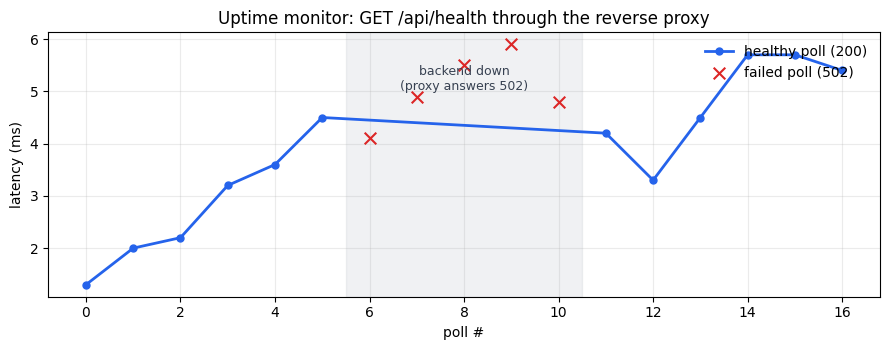

In [19]:
import matplotlib.pyplot as plt

ok = df_uptime[df_uptime["ok"]]
bad = df_uptime[~df_uptime["ok"]]
down_span = (df_uptime[df_uptime["phase"].str.startswith("2")]["poll"].min() - 0.5,
             df_uptime[df_uptime["phase"].str.startswith("2")]["poll"].max() + 0.5)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.axvspan(*down_span, color="#9CA3AF", alpha=0.15, zorder=0)
ax.plot(ok["poll"], ok["latency_ms"], marker="o", ms=5, lw=2,
        color="#2563EB", label="healthy poll (200)")
ax.scatter(bad["poll"], bad["latency_ms"], marker="x", s=70,
           color="#DC2626", zorder=3, label="failed poll (502)")
ax.annotate("backend down\n(proxy answers 502)",
            xy=(sum(down_span) / 2, ax.get_ylim()[1] * 0.82),
            ha="center", fontsize=9, color="#374151")
ax.set_xlabel("poll #")
ax.set_ylabel("latency (ms)")
ax.set_title("Uptime monitor: GET /api/health through the reverse proxy")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

> 🧠 **Metrics tell you *that* something is wrong; logs tell you *why*.** The chart screams "outage between two polls" — but only the **logs** can say *what* died. That's the incident flow from [monitoring.md](monitoring.md) §7: alert fires → glance at the graphs → drop into `docker compose logs backend`.

### Reading the diary — access-log analysis

Our proxy has been keeping a diary all along (`ACCESS_LOG` — its `/var/log/nginx/access.log`). Real nginx writes one line per request in the **combined** format; ours adds nginx's `$request_time` (seconds) at the end, a common production tweak:

```text
203.0.113.42 - - [02/Jul/2026:09:00:02 +0000] "GET /api/message HTTP/1.1" 200 38 "-" "Mozilla/5.0" 0.011
└── client IP        └── timestamp              └── request line        status┘ bytes┘  └ user-agent  └ seconds
```

Below is a 3-minute slice from a busy morning — 25 lines including a deploy hiccup (a burst of `502`s), a slow database endpoint, and a bot probing for WordPress. Parsing logs into a DataFrame turns war stories into queries.

In [20]:
LOG_SAMPLE = """\
203.0.113.42 - - [02/Jul/2026:09:00:01 +0000] "GET / HTTP/1.1" 200 512 "-" "Mozilla/5.0" 0.002
203.0.113.42 - - [02/Jul/2026:09:00:02 +0000] "GET /api/message HTTP/1.1" 200 38 "-" "Mozilla/5.0" 0.011
198.51.100.7 - - [02/Jul/2026:09:00:09 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.003
203.0.113.42 - - [02/Jul/2026:09:00:12 +0000] "GET /api/visits HTTP/1.1" 200 16 "-" "Mozilla/5.0" 0.482
198.51.100.23 - - [02/Jul/2026:09:00:15 +0000] "GET / HTTP/1.1" 200 512 "-" "Mozilla/5.0" 0.001
198.51.100.23 - - [02/Jul/2026:09:00:16 +0000] "GET /favicon.ico HTTP/1.1" 404 22 "-" "Mozilla/5.0" 0.001
198.51.100.7 - - [02/Jul/2026:09:00:39 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.002
203.0.113.42 - - [02/Jul/2026:09:00:41 +0000] "GET /api/visits HTTP/1.1" 200 16 "-" "Mozilla/5.0" 0.734
192.0.2.199 - - [02/Jul/2026:09:00:44 +0000] "GET /wp-admin/setup.php HTTP/1.1" 404 22 "-" "botnet-scanner/3.1" 0.001
198.51.100.23 - - [02/Jul/2026:09:00:52 +0000] "GET /api/message HTTP/1.1" 200 38 "-" "Mozilla/5.0" 0.009
198.51.100.7 - - [02/Jul/2026:09:01:09 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.004
203.0.113.42 - - [02/Jul/2026:09:01:11 +0000] "GET /api/visits HTTP/1.1" 500 42 "-" "Mozilla/5.0" 5.003
198.51.100.23 - - [02/Jul/2026:09:01:13 +0000] "GET /api/message HTTP/1.1" 502 97 "-" "Mozilla/5.0" 0.002
198.51.100.7 - - [02/Jul/2026:09:01:19 +0000] "GET /api/health HTTP/1.1" 502 97 "-" "uptime-monitor/1.0" 0.001
203.0.113.42 - - [02/Jul/2026:09:01:22 +0000] "GET /api/message HTTP/1.1" 502 97 "-" "Mozilla/5.0" 0.002
198.51.100.7 - - [02/Jul/2026:09:01:49 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.003
203.0.113.42 - - [02/Jul/2026:09:01:53 +0000] "GET /api/visits HTTP/1.1" 200 16 "-" "Mozilla/5.0" 0.912
198.51.100.23 - - [02/Jul/2026:09:01:57 +0000] "GET / HTTP/1.1" 200 512 "-" "Mozilla/5.0" 0.002
203.0.113.99 - - [02/Jul/2026:09:02:03 +0000] "GET /api/message HTTP/1.1" 200 38 "-" "Mozilla/5.0" 0.008
203.0.113.99 - - [02/Jul/2026:09:02:05 +0000] "GET /api/visits HTTP/1.1" 200 16 "-" "Mozilla/5.0" 1.204
198.51.100.7 - - [02/Jul/2026:09:02:19 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.002
203.0.113.99 - - [02/Jul/2026:09:02:21 +0000] "GET /api/slow HTTP/1.1" 504 101 "-" "Mozilla/5.0" 1.001
198.51.100.23 - - [02/Jul/2026:09:02:26 +0000] "GET / HTTP/1.1" 200 512 "-" "Mozilla/5.0" 0.001
203.0.113.99 - - [02/Jul/2026:09:02:31 +0000] "GET /api/message HTTP/1.1" 200 38 "-" "Mozilla/5.0" 0.007
198.51.100.7 - - [02/Jul/2026:09:02:49 +0000] "GET /api/health HTTP/1.1" 200 20 "-" "uptime-monitor/1.0" 0.003
"""

LOG_RE = re.compile(
    r'(?P<ip>\S+) \S+ \S+ \[(?P<time>[^\]]+)\] '
    r'"(?P<method>\S+) (?P<path>\S+) [^"]*" '
    r'(?P<status>\d{3}) (?P<bytes>\d+) "[^"]*" "(?P<agent>[^"]*)" (?P<request_time>[\d.]+)')

rows = [m.groupdict() for m in (LOG_RE.match(line) for line in LOG_SAMPLE.splitlines()) if m]
df_logs = pd.DataFrame(rows)
df_logs["time"] = pd.to_datetime(df_logs["time"], format="%d/%b/%Y:%H:%M:%S %z")
df_logs = df_logs.astype({"status": int, "bytes": int, "request_time": float})

print(f"parsed {len(df_logs)} log lines  (our own proxy's ACCESS_LOG parses with the same regex)\n")
print("status codes:")
print(df_logs["status"].value_counts().sort_index().to_string())
df_logs.head(3)

parsed 25 log lines  (our own proxy's ACCESS_LOG parses with the same regex)

status codes:
status
200    18
404     2
500     1
502     3
504     1


,ip,time,method,path,status,bytes,agent,request_time
0,203.0.113.42,2026-07-02 09:00:01+00:00,GET,/,200,512,Mozilla/5.0,0.002
1,203.0.113.42,2026-07-02 09:00:02+00:00,GET,/api/message,200,38,Mozilla/5.0,0.011
2,198.51.100.7,2026-07-02 09:00:09+00:00,GET,/api/health,200,20,uptime-monitor/1.0,0.003


Three questions, three one-liners — the **rate / errors / latency** trio the chapter says to watch (alert on *symptoms users feel*, not on every internal blip):

In [21]:
requests_per_min = df_logs.set_index("time").resample("1min")["status"].size()
print("request rate per minute:")
print(requests_per_min.to_string(), "\n")

error_rate = (df_logs["status"] >= 500).mean()
print(f"error rate: {error_rate:.1%} of requests returned a 5xx\n")

slow_paths = (df_logs.groupby("path")["request_time"]
              .agg(["count", "mean", "max"])
              .sort_values("mean", ascending=False))
print("latency by path (seconds):")
print(slow_paths.round(3).to_string())

request rate per minute:
time
2026-07-02 09:00:00+00:00    10
2026-07-02 09:01:00+00:00     8
2026-07-02 09:02:00+00:00     7
Freq: min 

error rate: 20.0% of requests returned a 5xx

latency by path (seconds):
                     count   mean    max
path                                    
/api/visits              5  1.667  5.003
/api/slow                1  1.001  1.001
/api/message             6  0.006  0.011
/api/health              7  0.003  0.004
/                        4  0.002  0.002
/favicon.ico             1  0.001  0.001
/wp-admin/setup.php      1  0.001  0.001


The table tells a story an operator reads in five seconds: `/api/visits` is the slow endpoint (it talks to the database — and one request took **5 seconds** before failing with a 500), the `502` burst at 09:01 was the deploy window, and the `404`s are a bot plus a missing favicon — noise, not signal.

> ⚠️ **The silent killer: unbounded logs.** Docker's default `json-file` driver grows forever; the #1 cause of "the server randomly died" on small deployments is a disk filled by unrotated container logs. Cap them on every service (`logging: options: max-size: "10m", max-file: "3"`) — [monitoring.md](monitoring.md) §3.4 calls this non-negotiable. Our list-based `ACCESS_LOG` would eat RAM the same way if this notebook ran for months.

---

### ✋ Quick exercise (~2 min) — The morning-report numbers

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your team's morning report needs three numbers from `df_logs`:

1. the **error rate** — share of requests with status ≥ 500;
2. the **p95 latency** in ms — `df_logs["request_time"].quantile(0.95)` (compare it with the **max**: what does the gap tell you?);
3. the **slowest path** by *mean* request time.

In [22]:
# ✍️ Your turn 👇
# error_rate = ...     # share of rows with status >= 500
# p95_s      = ...     # 95th percentile of request_time (seconds)
# slowest    = ...     # mean request_time per path, sorted descending
# print(f"error rate {error_rate:.1%} · p95 {p95_s*1000:.0f} ms · max {df_logs['request_time'].max()*1000:.0f} ms")
# print(slowest.head(3))
...

Ellipsis

<details>
<summary>✅ <b>Solution</b></summary>

```python
error_rate = (df_logs["status"] >= 500).mean()
p95_s = df_logs["request_time"].quantile(0.95)
slowest = df_logs.groupby("path")["request_time"].mean().sort_values(ascending=False)

print(f"error rate {error_rate:.1%} · p95 {p95_s*1000:.0f} ms · max {df_logs['request_time'].max()*1000:.0f} ms")
print(slowest.head(3).round(3).to_string())
```

Error rate: **20%** — way past any alert threshold; this 3-minute slice contains a real incident. The gap between **p95 (~1.2 s)** and **max (5 s)** is the lesson from the chapter's latency section: averages *and* single maxima both mislead — percentiles show what most users feel, while the max is one unlucky request. And the slowest path by mean is `/api/visits`, the database-backed endpoint — where you'd start optimizing (or caching).
</details>

## 7. ⚠️ The troubleshooting drill

Everything above eventually breaks in production — that's not failure, that's the job. What separates a seasoned operator is a **method** ([troubleshooting.md](troubleshooting.md)):

> Work **outside-in**, one layer at a time — browser → DNS → firewall → proxy → app container → database. Find the **first** unhealthy layer; everything downstream of it is a symptom, not the cause. Read the logs *at that layer*. Change one thing. Re-check.

The four failure shapes below cover ~90% of "the site is down" tickets. You've already built everything needed to stage each one — so let's *cause* all four, on purpose, and read their signatures:

In [23]:
front_door = f"http://127.0.0.1:{PROXY_PORT}"
DEAD_PORT = free_port(8938)     # verified free — and we deliberately start NOTHING there

print("── drill 1 · 502 Bad Gateway — proxy up, upstream down ─────────────────────")
real_upstream = UPSTREAMS["backend"]
UPSTREAMS["backend"] = f"http://127.0.0.1:{DEAD_PORT}"        # receptionist's directory → an empty room
resp = requests.get(front_door + "/api/health", timeout=3)
print(f"   status={resp.status_code} · {resp.json()['hint']}")
UPSTREAMS["backend"] = real_upstream                          # fix the directory
print(f"   upstream restored → status={requests.get(front_door + '/api/health', timeout=3).status_code}\n")

print("── drill 2 · 504 Gateway Timeout — upstream alive, but too slow ────────────")
# a new backend route that "hits a slow database" (sleep returns None, so `or` yields the dict)
BACKEND_ROUTES["/api/slow"] = lambda h: time.sleep(PROXY_TIMEOUT + 0.6) or {"finally": "done"}
resp = requests.get(front_door + "/api/slow", timeout=4)
print(f"   status={resp.status_code} · {resp.json()['hint']}\n")

print("── drill 3 · connection refused — NOTHING is listening at all ──────────────")
try:
    requests.get(f"http://127.0.0.1:{DEAD_PORT}/api/health", timeout=2)
except requests.exceptions.ConnectionError:
    print("   ConnectionError — no proxy, no app: nothing owns that port (crashed nginx? firewall? wrong port?)\n")

print("── drill 4 · NXDOMAIN — the name doesn't exist in DNS ──────────────────────")
try:
    resolve("checkout.example.com", quiet=True)
except NXDOMAIN as exc:
    print(f"   NXDOMAIN — {exc}  (the request never even left the phone book)")

── drill 1 · 502 Bad Gateway — proxy up, upstream down ─────────────────────
   status=502 · the proxy is fine, but the backend upstream is not answering — is the app container running?
   upstream restored → status=200

── drill 2 · 504 Gateway Timeout — upstream alive, but too slow ────────────


   status=504 · the upstream took longer than 1.0s to answer

── drill 3 · connection refused — NOTHING is listening at all ──────────────
   ConnectionError — no proxy, no app: nothing owns that port (crashed nginx? firewall? wrong port?)

── drill 4 · NXDOMAIN — the name doesn't exist in DNS ──────────────────────
   NXDOMAIN — ns1.example-dns.com: no A record for 'checkout.example.com'  (the request never even left the phone book)


Same site, same user complaint ("it's down!") — four completely different signatures. Here is the field guide, each row tied to something you just did:

| Symptom you see | First broken layer | What it means | First check (real stack) | Where you saw it |
|---|---|---|---|---|
| **`NXDOMAIN`** / "server not found" | DNS — the phone book | the name resolves to nothing; the request never leaves the browser | `dig +short example.com` — expect your server's IP | drill 4; §2's resolver raising `NXDOMAIN` |
| **connection refused / timeout** | server, firewall, or proxy | an IP was found, but *nothing answers* on that port | `sudo ufw status` (80/443 open?) · `docker compose ps` (is nginx up?) | drill 3; the 🧹 cleanup cell below |
| **`502 Bad Gateway`** | the upstream *behind* the proxy | receptionist at the desk; the room doesn't answer — container down/crashed/wrong port | `docker compose logs backend` · `docker compose exec nginx wget -qO- http://backend:8000/api/health` | drill 1; the §6 staged outage |
| **`504 Gateway Timeout`** | the upstream, slowly | the room answers, but slower than the receptionist is willing to wait | backend logs for slow queries; fix the endpoint or raise `proxy_read_timeout` | drill 2; `/api/slow` |

> 🧠 **The one-sentence mental model.** Each status tells you *how far the request got*: `NXDOMAIN` — never left the phone book; *refused* — reached the building, found no receptionist; `502` — receptionist, but no kitchen; `504` — kitchen, but the meal never came out. Locate the first silent layer and you've located the bug.

## 🧪 Practice exercises

### Exercise 1 — ⭐ Launch day for a second domain

Your team bought `python-lab.com` and wants it served by the *same* box at `203.0.113.10`. In the simulator: register the domain with the `.com` TLD (authoritative NS: `ns1.example-dns.com`), publish the two records from [dns.md](dns.md) §7 — an apex **A** record and a `www` **CNAME** — then `resolve()` both names to verify. Use a **low TTL (300)** on the apex and be ready to say why.

In [24]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1) register the domain (in real life: buy it at a registrar, which publishes NS records)
TLD_NAMESERVERS["com"]["python-lab.com"] = "ns1.example-dns.com"

# 2) publish the records — apex must be A/AAAA, subdomains may be CNAMEs
ZONE[("python-lab.com", "A")]         = {"value": "203.0.113.10", "ttl": 300}
ZONE[("www.python-lab.com", "CNAME")] = {"value": "python-lab.com", "ttl": 3600}

# 3) verify from the resolver — our `dig +short`
print(resolve("python-lab.com"), "\n")
print(resolve("www.python-lab.com"))
```

Both names land on `203.0.113.10`: the apex directly via its **A** record, `www` via a two-step **CNAME chase**. The apex TTL is a deliberate **300 s** because this is a brand-new setup you might still re-point — once it's stable you'd raise it (3600+) so the world's resolvers cache it efficiently. And per the chapter's rule: no CNAME at the apex, ever.
</details>

### Exercise 2 — ⭐⭐ A caching stub resolver

`resolve()` already caches inside the *recursive resolver* — but [dns.md](dns.md) §2 shows caches at **every** level. Build the OS-level one: a `CachingResolver` class with a `lookup(name, rtype="A")` method that

- serves fresh answers from its own TTL-aware cache (count these as `hits`),
- otherwise calls `resolve(name, rtype, quiet=True)` and caches the answer with the record's TTL (count these as `walks`).

Demonstrate: 5 lookups of `app.example.com` → 1 walk + 4 hits; then force-expire your cache entry and show the next lookup walks again.

In [25]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
class CachingResolver:
    """An OS-level stub resolver: its own TTL cache in front of the recursive walk."""

    def __init__(self):
        self.cache, self.hits, self.walks = {}, 0, 0

    def lookup(self, name: str, rtype: str = "A") -> str:
        entry = self.cache.get((name, rtype))
        if entry and entry[1] > time.time():          # fresh → answer instantly
            self.hits += 1
            return entry[0]
        self.walks += 1                               # stale/missing → full chain walk
        value = resolve(name, rtype, quiet=True)
        record = ZONE.get((name, rtype)) or ZONE.get((name, "CNAME")) or {"ttl": 60}
        self.cache[(name, rtype)] = (value, time.time() + record["ttl"])
        return value


stub = CachingResolver()
for _ in range(5):
    stub.lookup("app.example.com")
print(f"5 lookups → walks={stub.walks}, hits={stub.hits}")

value, _ = stub.cache[("app.example.com", "A")]
stub.cache[("app.example.com", "A")] = (value, time.time() - 1)   # TTL runs out
stub.lookup("app.example.com")
print(f"after expiry → walks={stub.walks}, hits={stub.hits}")
```

Output: `walks=1, hits=4`, then `walks=2, hits=4`. Multiply this by every browser, OS, and resolver on Earth and you understand both DNS's speed **and** why your record change takes a TTL to be seen everywhere — those caches don't know you changed anything; they just expire.
</details>

### Exercise 3 — ⭐⭐ Find the incident window

Zoom in on `df_logs` like an on-call engineer: bucket the traffic into **10-second windows** (`.set_index("time").resample("10s")`), compute per window the request count and the number of 5xx responses, derive an `error_rate` column, and print the worst window's start time. It should land squarely on the 09:01 deploy hiccup.

In [26]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
per_window = (df_logs.set_index("time").sort_index()
              .resample("10s")["status"]
              .agg(requests="size", errors=lambda s: int((s >= 500).sum())))
per_window["error_rate"] = (per_window["errors"] / per_window["requests"]).fillna(0.0)

busy = per_window[per_window["requests"] > 0]
print(busy.to_string(), "\n")

worst = busy["error_rate"].idxmax()
print(f"🚨 worst window starts {worst.strftime('%H:%M:%S')} — "
      f"{busy.loc[worst, 'errors']}/{busy.loc[worst, 'requests']} requests failed "
      f"({busy.loc[worst, 'error_rate']:.0%})")
```

The 09:01:10 window is a wall of red — `500` then back-to-back `502`s: the deploy restarted the backend while traffic flowed. This windowed error rate is precisely the metric you'd graph in Grafana and alert on ("page me when the 1-minute 5xx rate exceeds 5%") — a dashboard nobody watches is not monitoring, the chapter reminds us; **alerts** are.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

A teammate "cleaned up" the forwarding logic in a code review: *"the `/api` prefix is redundant — strip it before calling the upstream, nginx does that anyway."* Since the change, **every** API call through their build fails. The cell below reproduces their code against our live backend — run it, read the traceback, and explain (a) why it breaks and (b) the two possible fixes, before opening the solution.

In [27]:
# Your code here  👇  (run it first — then explain the bug)

def forward_api(path: str) -> dict:
    """Forward an /api/* request to the backend upstream. (BUGGY — but why?)"""
    upstream_path = path.removeprefix("/api")          # "tidy": strip the prefix
    resp = requests.get(f"http://127.0.0.1:{BACKEND_PORT}{upstream_path}", timeout=2)
    resp.raise_for_status()
    return resp.json()

forward_api("/api/health")

HTTPError: 404 Client Error: Not Found for url: http://127.0.0.1:8931/health

<details>
<summary>💡 <b>Solution</b></summary>

```python
def forward_api_fixed(path: str) -> dict:
    resp = requests.get(f"http://127.0.0.1:{BACKEND_PORT}{path}", timeout=2)   # keep the prefix
    resp.raise_for_status()
    return resp.json()

print(forward_api_fixed("/api/health"))
```

**(a) Why it breaks.** The buggy version rewrites `/api/health` → `/health` before forwarding — but the backend's routes are *defined with* the prefix (`/api/health`, mirroring `@app.get("/api/health")` in the real FastAPI app). The backend correctly answers `404 Not Found`, and `raise_for_status()` turns that into the `HTTPError` you saw.

**(b) The two fixes** — the same pair as [reverse-proxies.md](reverse-proxies.md)'s trailing-slash trap, because this *is* that trap in Python clothing:
1. **Don't strip** — forward the full path unchanged (what our proxy and the shipped `proxy_pass http://backend_upstream;` — no trailing slash — both do). ✅ simplest.
2. Keep stripping, but **redefine the backend routes without the prefix** (`/health`), i.e. make both sides agree.

The teammate's claim was half-true: nginx strips the prefix **only** when `proxy_pass` ends with a `/`. Whether the prefix survives the proxy is a *deliberate contract* between proxy and app — decide it once, and make both sides honor it.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ A load balancer in 20 lines

[reverse-proxies.md](reverse-proxies.md) §1 says most reverse proxies *can* load-balance: nginx would just list several `server` lines in the `upstream` block. Prove the concept: start a **second** backend "container" (`start_backend(free_port(8933))`), put both base URLs in a pool, and write `balanced_get(path)` that **round-robins** across the pool (`itertools.cycle`) and **fails over** — if the chosen member refuses the connection, it silently tries the next. Demonstrate alternation across 4 calls, then stop one member and show requests keep succeeding.

In [28]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
import itertools

BACKEND2_PORT = free_port(8933)
backend2_server = start_backend(BACKEND2_PORT)          # nginx: add `server backend2:8000;`

POOL = [f"http://127.0.0.1:{BACKEND_PORT}", f"http://127.0.0.1:{BACKEND2_PORT}"]
rotation = itertools.cycle(range(len(POOL)))

def balanced_get(path: str) -> dict:
    """Round-robin across POOL; skip members that refuse the connection."""
    for _ in range(len(POOL)):                          # at most one full lap
        member = POOL[next(rotation)]
        try:
            resp = requests.get(member + path, timeout=1.0)
            return {"served_by": member, "status": resp.status_code}
        except requests.exceptions.ConnectionError:
            continue                                    # dead member — try the next
    return {"served_by": None, "status": 502}           # the whole pool is down

for _ in range(4):
    print(balanced_get("/api/health"))                  # alternates between the two ports

backend2_server.shutdown(); backend2_server.server_close()
print("\nbackend2 stopped — the balancer fails over:")
for _ in range(3):
    print(balanced_get("/api/health"))                  # only the survivor answers
```

Round-robin + skip-the-dead is the essence of what `upstream` blocks give you for free — plus health-aware routing, weights, and connection pooling. When one member dies, users notice nothing: that's the *resilience* half of load balancing (the other half, capacity, you'd see under real traffic).
</details>

### Stretch exercise B — ⭐⭐⭐ Verify the chain of trust

Play browser for real. Model certificates as dicts with `subject`, `issuer`, `not_after`, and a toy `signature` of the form `signed(<subject>)-by(<issuer>)`. Write `verify_chain(leaf, intermediates, hostname)` that walks leaf → intermediate(s) → root exactly like §5 described: **name matches**, every link's **signature** checks out against its issuer, the chain **ends in `TRUST_STORE`**, nothing **expired**. Return `(ok, reason)`. Test the happy path plus at least two failures (missing intermediate, wrong hostname).

In [29]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
def make_cert(subject: str, issuer: str, days: int = 90) -> dict:
    return {"subject": subject, "issuer": issuer,
            "not_after": (datetime.now(timezone.utc) + timedelta(days=days)).isoformat(timespec="seconds"),
            "signature": f"signed({subject})-by({issuer})"}

leaf  = make_cert("app.example.com", "Lab Intermediate CA X9")
inter = make_cert("Lab Intermediate CA X9", "Lab Root CA R1")

def verify_chain(leaf: dict, intermediates: list[dict], hostname: str) -> tuple[bool, str]:
    if hostname != leaf["subject"]:
        return False, f"name mismatch: cert is for {leaf['subject']!r}, not {hostname!r}"
    by_subject = {c["subject"]: c for c in intermediates}
    chain, cert = [leaf], leaf
    while cert["issuer"] not in TRUST_STORE:            # climb until we hit a root we trust
        issuer_cert = by_subject.get(cert["issuer"])
        if issuer_cert is None:
            return False, f"broken chain: no certificate presented for {cert['issuer']!r}"
        if cert["signature"] != f"signed({cert['subject']})-by({issuer_cert['subject']})":
            return False, f"bad signature on {cert['subject']!r}"
        cert = issuer_cert
        chain.append(cert)
    now_iso = datetime.now(timezone.utc).isoformat(timespec="seconds")
    for link in chain:
        if link["not_after"] <= now_iso:
            return False, f"{link['subject']!r} has expired"
    return True, " → ".join(c["subject"] for c in chain) + f" → {cert['issuer']} (trusted root ✅)"

print(verify_chain(leaf, [inter], "app.example.com"))   # happy path
print(verify_chain(leaf, [],      "app.example.com"))   # server forgot the intermediate
print(verify_chain(leaf, [inter], "evil.example.net"))  # stolen cert, wrong site
```

The "server forgot the intermediate" case is a real-world classic: the site works in Chrome (which caches intermediates) but fails on fresh devices — always serve `fullchain.pem`, not just the leaf. And the wrong-hostname case is exactly why a stolen certificate is useless without the matching domain *and* private key.
</details>

### Stretch exercise C — ⭐⭐⭐ Page me once, not forty times

Your §6 monitor produced `df_uptime`, which contains a genuine outage. Naive alerting sends one message **per failed poll** — the "alert fatigue" [monitoring.md](monitoring.md) §6 warns about, and the fastest way to train a team to ignore its pager. Write `alert_on_incidents(df, threshold=3)` that walks the polls in order and fires **exactly one** `🚨 PAGE` when a run of `threshold` consecutive failures begins, and **one** `✅ recovered` when the next success arrives. Run it on `df_uptime`: expect exactly two messages.

In [30]:
# Your code here  👇

<details>
<summary>💡 <b>Solution</b></summary>

```python
def alert_on_incidents(df: pd.DataFrame, threshold: int = 3) -> list[str]:
    """Alert on state CHANGES, not on every bad poll."""
    messages, streak, paging = [], 0, False
    for _, row in df.iterrows():
        streak = 0 if row["ok"] else streak + 1
        if not paging and streak >= threshold:
            paging = True
            messages.append(f"🚨 PAGE: /api/health — {threshold} consecutive failures (from poll #{row['poll']})")
        elif paging and row["ok"]:
            paging = False
            messages.append(f"✅ recovered: /api/health responding again (poll #{row['poll']})")
    return messages

for message in alert_on_incidents(df_uptime):
    print(message)
```

Two lines out of a 17-poll incident: one page, one all-clear. The `threshold=3` guard also absorbs a single flaky poll (network blip ≠ outage) — the same reason Docker's `HEALTHCHECK` uses `--retries=3` before marking a container unhealthy. Alert on **state transitions of symptoms users feel**; graph everything else.
</details>

## 🎁 Bonus mini-project — The one-file status page

Every serious service has a public status page (status.github.com, status.aws.amazon.com…). You have every ingredient to build one for *this* stack — and serve it with the same machinery you've used all lab.

**Build `render_status_page() -> str`** that assembles an HTML page from live lab state:

1. 🟢/🔴 **current status** — one fresh `check_health(HEALTH_URL)` probe;
2. **availability** — `df_uptime["ok"].mean()` across the §6 incident, plus failure count;
3. **certificate box** — subject, issuer, and *days until expiry* of `cert` (your checkpoint-3 function);
4. **recent errors** — the last few 5xx lines from `df_logs` as a small HTML table (`.to_html()`);
5. serve it from a **third** `QuietServer` on `free_port(8934)` with a tiny handler, fetch it with `requests`, and print the first lines — a status page *about* your stack, *served by* your stack.

<details>
<summary>💡 <b>Solution sketch</b></summary>

```python
def render_status_page() -> str:
    probe = check_health(HEALTH_URL)
    light = "🟢 operational" if probe["ok"] else "🔴 outage"
    recent_errors = df_logs[df_logs["status"] >= 500][["time", "path", "status"]]
    return f"""<!doctype html>
    <title>status — example.com</title>
    <h1>{light}</h1>
    <p>last probe: {probe['status']} in {probe['latency_ms']} ms</p>
    <p>availability (last incident window): {df_uptime['ok'].mean():.0%}
       — {int((~df_uptime['ok']).sum())} failed polls</p>
    <p>🪪 TLS: {cert['subject']} · issued by {cert['issuer']} ·
       {days_until_expiry(cert)} days to expiry</p>
    <h2>recent 5xx</h2>{recent_errors.to_html(index=False)}"""

STATUS_ROUTES = {"/": render_status_page}

class StatusHandler(BaseHTTPRequestHandler):
    def do_GET(self):
        body = STATUS_ROUTES.get(self.path, lambda: "<h1>404</h1>")().encode()
        self.send_response(200 if self.path in STATUS_ROUTES else 404)
        self.send_header("Content-Type", "text/html")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)
    def log_message(self, *_):
        pass

STATUS_PORT = free_port(8934)
serve_on_thread(QuietServer(("127.0.0.1", STATUS_PORT), StatusHandler), name=f"status:{STATUS_PORT}")
print(requests.get(f"http://127.0.0.1:{STATUS_PORT}/", timeout=2).text[:400])
```

Extensions if you're enjoying yourself: embed the §6 latency chart as a base64 `<img>`; add `needs_renewal(cert)` as a 🟡 warning state; regenerate the page on every request (it already does — each GET calls `render_status_page()` fresh, so re-running the monitor updates the page). In production you'd render this from Prometheus queries instead of DataFrames — but the shape is identical: *probe, aggregate, publish*.
</details>

## 🧹 Cleanup — stop every server

A tidy operator never leaves services running after the work is done — this is our `docker compose down`. Every server registered itself in `RUNNING_SERVERS` back in §1, so one loop shuts down the backend(s), the proxy, and anything you started in the exercises. (They're all daemon threads, so they'd die with the kernel anyway — but *deliberate* shutdown is the habit that matters.)

In [31]:
print(f"stopping {len(RUNNING_SERVERS)} server(s) …")
for server in RUNNING_SERVERS:
    try:
        server.shutdown()          # politely stop serve_forever()
        server.server_close()      # release the port back to the OS
    except Exception as exc:       # already stopped (e.g. our staged outage) — that's fine
        print(f"   (already stopped: {exc})")
RUNNING_SERVERS.clear()

# proof — the probe that worked all lab now finds nobody home (drill 3's signature!):
print("\nproxy after shutdown:", check_health(f"http://127.0.0.1:{PROXY_PORT}/api/health"))
print(f"\n🧹 done — ports {PORT_LO}-{PORT_HI} are free again. (docker compose down, notebook edition.)")

stopping 3 server(s) …



proxy after shutdown: {'ok': False, 'status': None, 'latency_ms': 2.2, 'error': 'ConnectionError'}

🧹 done — ports 8931-8939 are free again. (docker compose down, notebook edition.)


## 🧠 Key takeaways

> 🧭 **The story in one line.** We walked one request's entire journey and built every station ourselves: the **phone book** (DNS as three nested dictionaries + TTL caches), the **receptionist** (a 40-line reverse proxy that routes by path, restores the caller's identity, and fails honestly with 502/504), the **sealed envelope** (a certificate issued only after the ACME HTTP-01 challenge proved domain control), and the **instruments** (an uptime monitor and access-log analytics that caught our staged outage) — then drilled the four failure signatures until they're reflexes.

1. **DNS is indirection plus caching.** Names → IPs via root → TLD → authoritative; every layer caches for the TTL. "Propagation" is caches *expiring*, so lower TTLs *before* migrations. Apex = A/AAAA; subdomains = CNAME.
2. **One front door.** Only the reverse proxy faces the internet; backends stay on the private network. Route by path, most-specific first.
3. **Forwarded headers are the receptionist's manners.** `Host`, `X-Real-IP`, `X-Forwarded-For`, `X-Forwarded-Proto` — drop them and logs lie, redirects loop, cookies leak.
4. **The prefix contract is deliberate.** `proxy_pass` with/without a trailing slash decides whether `/api/` survives — proxy and app must agree (Exercise 4's bug in one sentence).
5. **A certificate asserts a name, nothing more** — signed by a chain your browser can walk to a trusted root. SNI lets one IP serve many certs.
6. **HTTPS is automated or it is broken.** ACME HTTP-01: token → served on port 80 → CA fetches → 90-day cert. DNS correct *first*; renewal timer *verified*.
7. **TLS terminates at the proxy;** internal traffic stays plain HTTP on the private network — hence `X-Forwarded-Proto`.
8. **Monitor symptoms users feel** — rate, errors, latency (percentiles, not averages). Metrics say *that*, logs say *why*. Alert on state changes, not every bad poll; rotate your logs before they eat the disk.
9. **Diagnose outside-in.** `NXDOMAIN` → phone book; *refused* → nobody listening; `502` → upstream down; `504` → upstream slow. Find the first silent layer.

## ✅ Self-assessment

- [ ] Sketch the request journey (browser → DNS → IP:443 → proxy → container) and name one failure per hop
- [ ] Walk a DNS resolution by hand: which server answers what, and where the answer gets cached
- [ ] Explain why a CNAME can't live at the apex, and when to lower a TTL
- [ ] Write a path-routing reverse proxy that adds `X-Forwarded-For` and returns a friendly 502
- [ ] Map `upstream`, `location`, `proxy_pass`, and `proxy_set_header` onto their Python twins
- [ ] Narrate the ACME HTTP-01 challenge and say why DNS and port 80 must work first
- [ ] Read an access log into pandas and produce error rate, p95 latency, and slowest paths
- [ ] Tell apart 502 / 504 / connection refused / NXDOMAIN — and name the first check for each

## 🚀 Next step

You've now built — by hand, offline — every component the module's chapters describe. Two directions from here:

- **Go live for real:** [tutorial.md](tutorial.md) is the guided end-to-end walkthrough — rent the Ubuntu server, point *real* DNS records at it, run *real* certbot, and ship the example app with the CI/CD pipeline from `lab02_ci_pipeline_github_actions.ipynb` (containers from `lab01_docker_and_compose.ipynb`). [exercises.md](exercises.md) has more drills when you want them. Your uptime monitor from §6 is one cron line away from production — NB 46 taught you exactly how to schedule it.
- **Then: Module 15 — Capstones.** Notebook 47 (`../15_capstones/47_capstone_analytics.ipynb`) and Notebook 48 (`../15_capstones/48_capstone_ai_assistant.ipynb`) are end-to-end builds that *deserve* the deployment story you can now give them.

> 🚀 Open a notebook. Edit one number. Re-run. Iterate. *That* is the whole craft.